In [ ]:
from scipy.stats import ttest_ind

# Confidence in ratio

ratio_no_interp = [2, 5, 1, 5, 5, 7, 1]
ratio_yes_interp = [1, 1, 1, 1, 3, 5, 1, 6]

ttest_ind(ratio_no_interp, ratio_yes_interp, equal_var=False)


TtestResult(statistic=np.float64(1.1615698098362626), pvalue=np.float64(0.26783872598763636), df=np.float64(12.085083052713042))

In [ ]:
### Confidence in INSIGHT

from scipy.stats import ttest_ind

insight_no_interp = [7, 7, 6, 6, 7, 7]
insight_yes_interp = [5, 5, 5, 5, 5, 5, 7]

ttest_ind(insight_no_interp, insight_yes_interp, equal_var=False)


TtestResult(statistic=np.float64(3.889202910697197), pvalue=np.float64(0.0027229798711380666), df=np.float64(10.556769751939681))

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confidence_bar_charts.png'

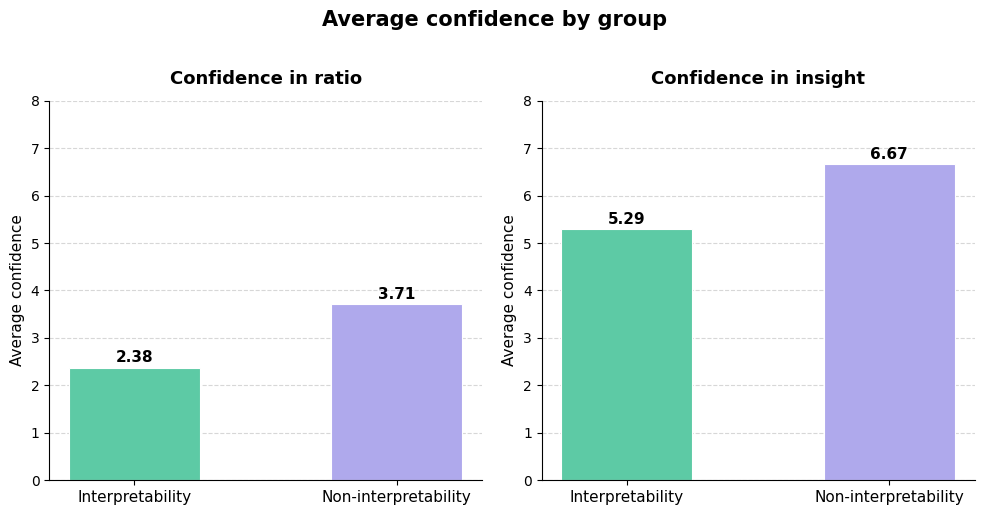

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
ratio_interp = ratio_yes_interp
ratio_non = ratio_no_interp

insight_interp = insight_yes_interp
insight_non = insight_no_interp

# Averages
means = {
    "ratio": [np.mean(ratio_interp), np.mean(ratio_non)],
    "insight": [np.mean(insight_interp), np.mean(insight_non)],
}

labels = ["Interpretability", "Non-interpretability"]
colors = ["#5DCAA5", "#AFA9EC"]
x = np.arange(len(labels))
width = 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
titles = ["Confidence in ratio", "Confidence in insight"]

for ax, key, title in zip(axes, ["ratio", "insight"], titles):
    bars = ax.bar(x, means[key], width=width, color=colors, edgecolor="white", linewidth=0.8)

    # Value labels on bars
    for bar, val in zip(bars, means[key]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Average confidence", fontsize=11)
    ax.set_ylim(0, 8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Average confidence by group", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/confidence_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confidence_bar_charts.png'

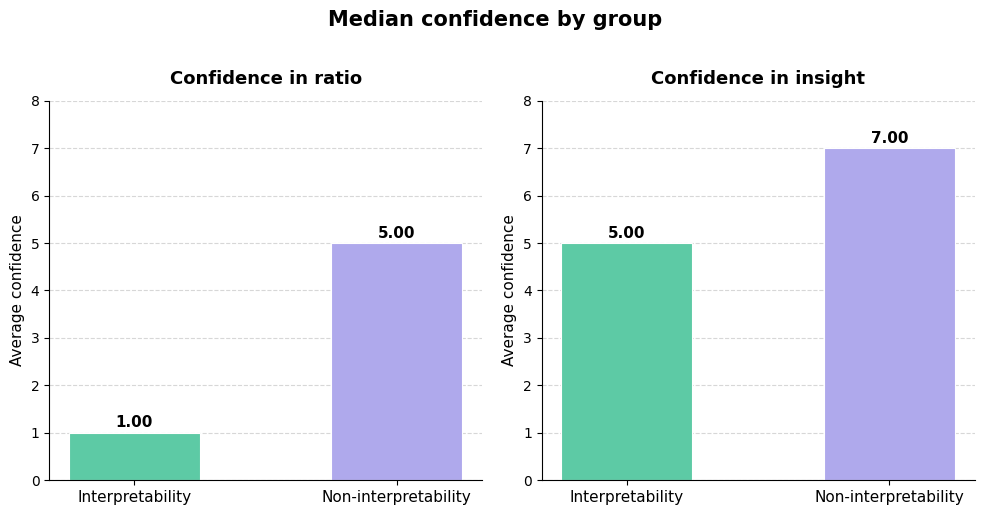

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
ratio_interp = ratio_yes_interp
ratio_non = ratio_no_interp

insight_interp = insight_yes_interp
insight_non = insight_no_interp

# Averages
medians = {
    "ratio": [np.median(ratio_interp), np.median(ratio_non)],
    "insight": [np.median(insight_interp), np.median(insight_non)],
}

labels = ["Interpretability", "Non-interpretability"]
colors = ["#5DCAA5", "#AFA9EC"]
x = np.arange(len(labels))
width = 0.5

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
titles = ["Confidence in ratio", "Confidence in insight"]

for ax, key, title in zip(axes, ["ratio", "insight"], titles):
    bars = ax.bar(x, medians[key], width=width, color=colors, edgecolor="white", linewidth=0.8)

    # Value labels on bars
    for bar, val in zip(bars, medians[key]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Average confidence", fontsize=11)
    ax.set_ylim(0, 8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Median confidence by group", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/confidence_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confidence_dot_plots.png'

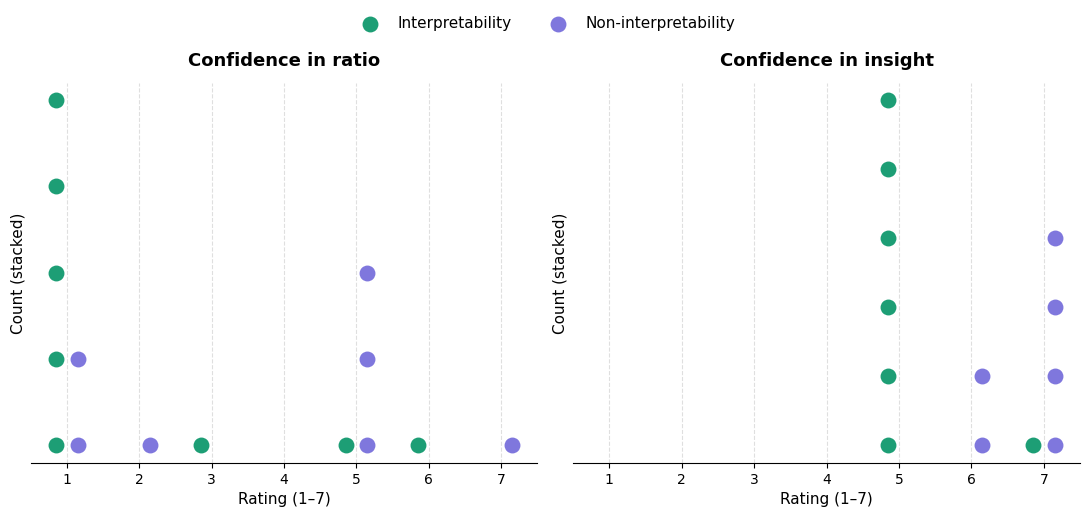

In [ ]:
from collections import Counter

colors = {"Interpretability": "#1D9E75", "Non-interpretability": "#7F77DD"}

def stacked_scatter(ax, data_dict, title):
    offsets = {"Interpretability": -0.15, "Non-interpretability": 0.15}

    for label, values in data_dict.items():
        counts = Counter()
        xs, ys = [], []
        for v in sorted(values):
            counts[v] += 1
            xs.append(v + offsets[label])
            ys.append(counts[v])
        ax.scatter(xs, ys, color=colors[label], s=160, zorder=3,
                   edgecolors="white", linewidths=1.2, label=label)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Rating (1–7)", fontsize=11)
    ax.set_xlim(0.5, 7.5)
    ax.set_xticks(range(1, 8))
    ax.set_yticks([])
    ax.set_ylabel("Count (stacked)", fontsize=11)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

stacked_scatter(axes[0],
    {"Interpretability": ratio_interp, "Non-interpretability": ratio_non},
    "Confidence in ratio")

stacked_scatter(axes[1],
    {"Interpretability": insight_interp, "Non-interpretability": insight_non},
    "Confidence in insight")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=11,
           frameon=False, bbox_to_anchor=(0.5, 1.04),
           markerscale=1.0)

fig.suptitle("", y=1.08)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/confidence_dot_plots.png", dpi=150, bbox_inches="tight")
plt.show()